# Module 1 — Pose Estimation
### Virtual Fashion Fitting Room

This notebook builds the pose estimation module from scratch.

**What this module does:**
- Takes a person image as input
- Detects 18 body keypoints (COCO format)
- Generates a pose heatmap and skeleton visualisation
- Saves keypoints as JSON — the exact format HR-VITON expects

**Why this matters:**  
The pose skeleton tells the GAN *where* the body is and how it is positioned, so the garment can be warped to fit correctly. Without accurate pose, the try-on output will be misaligned.

---

## Step 1 — Install dependencies

In [1]:
# Run this cell once. Restart kernel after installation.
!pip install mediapipe opencv-python-headless matplotlib numpy Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 12.6 MB/s  0:00:03m0:00:0100:01


## Step 2 — Imports

In [1]:
import cv2
import json
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image

print(f"MediaPipe version : {mp.__version__}")
print(f"OpenCV version    : {cv2.__version__}")

objc[80320]: Class CaptureDelegate is implemented in both /Users/purveshg/anaconda3/envs/vfr-env/lib/python3.10/site-packages/cv2/cv2.abi3.so (0x12993e688) and /Users/purveshg/anaconda3/envs/vfr-env/lib/python3.10/site-packages/mediapipe/.dylibs/libopencv_videoio.3.4.16.dylib (0x12d130860). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[80320]: Class CVWindow is implemented in both /Users/purveshg/anaconda3/envs/vfr-env/lib/python3.10/site-packages/cv2/cv2.abi3.so (0x12993e6d8) and /Users/purveshg/anaconda3/envs/vfr-env/lib/python3.10/site-packages/mediapipe/.dylibs/libopencv_highgui.3.4.16.dylib (0x12a358a68). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[80320]: Class CVView is implemented in both /Users/purveshg/anaconda3/envs/vfr-env/lib/python3.10/site-packages/cv2/cv2.abi3.so (0x12993e700) and /Users/purveshg/anaconda3/envs/vfr-env/lib

MediaPipe version : 0.9.2.1
OpenCV version    : 4.13.0


## Step 3 — COCO-18 keypoint mapping

HR-VITON expects keypoints in **COCO-18 format**. MediaPipe gives us 33 landmarks,  
so we map the relevant ones across.

| Index | COCO keypoint   | MediaPipe landmark |
|-------|-----------------|--------------------|
| 0     | Nose            | 0                  |
| 1     | Neck            | midpoint(11, 12)   |
| 2     | Right shoulder  | 12                 |
| 3     | Right elbow     | 14                 |
| 4     | Right wrist     | 16                 |
| 5     | Left shoulder   | 11                 |
| 6     | Left elbow      | 13                 |
| 7     | Left wrist      | 15                 |
| 8     | Right hip       | 24                 |
| 9     | Right knee      | 26                 |
| 10    | Right ankle     | 28                 |
| 11    | Left hip        | 23                 |
| 12    | Left knee       | 25                 |
| 13    | Left ankle      | 27                 |
| 14    | Right eye       | 5                  |
| 15    | Left eye        | 2                  |
| 16    | Right ear       | 8                  |
| 17    | Left ear        | 7                  |

In [2]:
# COCO-18 keypoint names
COCO_KEYPOINTS = [
    'nose', 'neck',
    'right_shoulder', 'right_elbow', 'right_wrist',
    'left_shoulder',  'left_elbow',  'left_wrist',
    'right_hip', 'right_knee', 'right_ankle',
    'left_hip',  'left_knee',  'left_ankle',
    'right_eye', 'left_eye',
    'right_ear', 'left_ear'
]

# Skeleton connections — pairs of keypoint indices
# Used for drawing the skeleton overlay
SKELETON_CONNECTIONS = [
    (0, 1),   # nose -> neck
    (1, 2),   # neck -> right shoulder
    (1, 5),   # neck -> left shoulder
    (2, 3),   # right shoulder -> right elbow
    (3, 4),   # right elbow -> right wrist
    (5, 6),   # left shoulder -> left elbow
    (6, 7),   # left elbow -> left wrist
    (1, 8),   # neck -> right hip (approximate torso)
    (1, 11),  # neck -> left hip
    (8, 9),   # right hip -> right knee
    (9, 10),  # right knee -> right ankle
    (11, 12), # left hip -> left knee
    (12, 13), # left knee -> left ankle
    (8, 11),  # right hip -> left hip
]

# Colour per joint group (RGB) for visualisation
JOINT_COLORS = {
    'head':       (255, 200,  50),  # amber
    'right_arm':  (255,  80,  80),  # red
    'left_arm':   ( 80, 150, 255),  # blue
    'torso':      (100, 220, 100),  # green
    'right_leg':  (255, 150,  80),  # orange
    'left_leg':   (180,  80, 255),  # purple
}

# Map keypoint index to colour group
KP_COLOR_MAP = [
    'head', 'torso',
    'right_arm', 'right_arm', 'right_arm',
    'left_arm',  'left_arm',  'left_arm',
    'right_leg', 'right_leg', 'right_leg',
    'left_leg',  'left_leg',  'left_leg',
    'head', 'head', 'head', 'head'
]

print(f"Total keypoints    : {len(COCO_KEYPOINTS)}")
print(f"Skeleton connections: {len(SKELETON_CONNECTIONS)}")

Total keypoints    : 18
Skeleton connections: 14


## Step 4 — PoseEstimator class

In [3]:
class PoseEstimator:
    """
    Wraps MediaPipe Pose to extract COCO-18 keypoints from a person image.

    Usage:
        estimator = PoseEstimator()
        result = estimator.process('person.jpg')
    """

    def __init__(self, min_detection_confidence=0.5, min_tracking_confidence=0.5):
        self.mp_pose   = mp.solutions.pose
        self.mp_draw   = mp.solutions.drawing_utils
        self.pose      = self.mp_pose.Pose(
            static_image_mode=True,              # single image, not video
            model_complexity=2,                  # 0=lite, 1=full, 2=heavy (most accurate)
            enable_segmentation=True,            # also gives us a person mask — useful later
            min_detection_confidence=min_detection_confidence,
            min_tracking_confidence=min_tracking_confidence
        )

    def _mediapipe_to_coco18(self, landmarks, img_w, img_h):
        """
        Convert MediaPipe's 33 landmarks to COCO-18 keypoints.
        Returns a list of (x, y, confidence) tuples in pixel coordinates.
        Undetected points are returned as (0, 0, 0).
        """
        lm = landmarks.landmark

        def get(idx):
            """ Return pixel (x, y, visibility) for a MediaPipe landmark index. """
            p = lm[idx]
            return (int(p.x * img_w), int(p.y * img_h), float(p.visibility))

        def midpoint(i, j):
            """ Return pixel midpoint between two landmarks (used for neck). """
            xi, yi, vi = get(i)
            xj, yj, vj = get(j)
            return (int((xi + xj) / 2), int((yi + yj) / 2), float((vi + vj) / 2))

        # Build COCO-18 list following the mapping table above
        coco_kps = [
            get(0),           # 0  nose
            midpoint(11, 12), # 1  neck
            get(12),          # 2  right shoulder
            get(14),          # 3  right elbow
            get(16),          # 4  right wrist
            get(11),          # 5  left shoulder
            get(13),          # 6  left elbow
            get(15),          # 7  left wrist
            get(24),          # 8  right hip
            get(26),          # 9  right knee
            get(28),          # 10 right ankle
            get(23),          # 11 left hip
            get(25),          # 12 left knee
            get(27),          # 13 left ankle
            get(5),           # 14 right eye
            get(2),           # 15 left eye
            get(8),           # 16 right ear
            get(7),           # 17 left ear
        ]
        return coco_kps

    def process(self, image_path):
        """
        Run pose estimation on an image file.

        Args:
            image_path: str or Path to the input image

        Returns:
            dict with keys:
                'keypoints'   : list of 18 (x, y, conf) tuples
                'image'       : original BGR image (numpy)
                'mask'        : binary person segmentation mask
                'detected'    : bool — was a person found?
        """
        # Load image
        img_bgr = cv2.imread(str(image_path))
        if img_bgr is None:
            raise FileNotFoundError(f"Could not read image: {image_path}")

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w    = img_rgb.shape[:2]

        # Run MediaPipe
        results = self.pose.process(img_rgb)

        if not results.pose_landmarks:
            print("WARNING: No person detected in image.")
            return {
                'keypoints': [(0, 0, 0)] * 18,
                'image':     img_bgr,
                'mask':      np.zeros((h, w), dtype=np.uint8),
                'detected':  False
            }

        # Extract COCO-18 keypoints
        keypoints = self._mediapipe_to_coco18(results.pose_landmarks, w, h)

        # Extract segmentation mask (person vs background)
        mask = np.zeros((h, w), dtype=np.uint8)
        if results.segmentation_mask is not None:
            seg = results.segmentation_mask
            mask = (seg > 0.5).astype(np.uint8) * 255

        return {
            'keypoints': keypoints,
            'image':     img_bgr,
            'mask':      mask,
            'detected':  True,
            'raw':       results  # keep raw results in case you need them later
        }

    def close(self):
        self.pose.close()

print("PoseEstimator class defined.")

PoseEstimator class defined.


## Step 5 — Visualisation helpers

In [4]:
def draw_skeleton(image_bgr, keypoints, conf_threshold=0.3):
    """
    Draw skeleton overlay on a copy of the image.

    Args:
        image_bgr     : numpy BGR image
        keypoints     : list of 18 (x, y, conf) tuples
        conf_threshold: minimum confidence to draw a joint

    Returns:
        annotated BGR image
    """
    canvas = image_bgr.copy()

    # Draw skeleton connections first (so joints appear on top)
    for (i, j) in SKELETON_CONNECTIONS:
        xi, yi, ci = keypoints[i]
        xj, yj, cj = keypoints[j]
        if ci < conf_threshold or cj < conf_threshold:
            continue
        color_rgb = JOINT_COLORS.get(KP_COLOR_MAP[i], (200, 200, 200))
        color_bgr = color_rgb[::-1]  # matplotlib RGB -> OpenCV BGR
        cv2.line(canvas, (xi, yi), (xj, yj), color_bgr, thickness=2, lineType=cv2.LINE_AA)

    # Draw joint circles
    for idx, (x, y, conf) in enumerate(keypoints):
        if conf < conf_threshold:
            continue
        color_rgb = JOINT_COLORS.get(KP_COLOR_MAP[idx], (200, 200, 200))
        color_bgr = color_rgb[::-1]
        cv2.circle(canvas, (x, y), radius=6, color=color_bgr, thickness=-1, lineType=cv2.LINE_AA)
        cv2.circle(canvas, (x, y), radius=6, color=(255, 255, 255), thickness=1, lineType=cv2.LINE_AA)

    return canvas


def generate_pose_heatmap(keypoints, img_h, img_w, sigma=8):
    """
    Generate a Gaussian heatmap for each keypoint.
    This is the format the GAN model uses as pose input — NOT the RGB skeleton image.

    Args:
        keypoints : list of 18 (x, y, conf) tuples
        img_h     : image height
        img_w     : image width
        sigma     : Gaussian spread (larger = broader heatmap peaks)

    Returns:
        heatmaps  : numpy array of shape (18, H, W) with float32 values in [0, 1]
    """
    heatmaps = np.zeros((len(keypoints), img_h, img_w), dtype=np.float32)

    # Precompute coordinate grids
    ys = np.arange(img_h)
    xs = np.arange(img_w)
    xx, yy = np.meshgrid(xs, ys)

    for idx, (x, y, conf) in enumerate(keypoints):
        if conf < 0.1:
            continue  # skip undetected joints — leave channel as zeros
        gauss = np.exp(-((xx - x) ** 2 + (yy - y) ** 2) / (2 * sigma ** 2))
        heatmaps[idx] = gauss

    return heatmaps


def visualise_heatmap_grid(heatmaps, keypoints):
    """
    Display all 18 heatmap channels in a grid.
    Useful for debugging — check each joint's heatmap looks correct.
    """
    fig, axes = plt.subplots(3, 6, figsize=(16, 8))
    fig.suptitle('Pose heatmaps — one channel per joint', fontsize=13)

    for idx, ax in enumerate(axes.flat):
        if idx >= len(COCO_KEYPOINTS):
            ax.axis('off')
            continue
        ax.imshow(heatmaps[idx], cmap='hot', vmin=0, vmax=1)
        conf = keypoints[idx][2]
        label_color = 'lime' if conf >= 0.3 else 'red'
        ax.set_title(COCO_KEYPOINTS[idx], fontsize=8, color=label_color)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def show_results(result, conf_threshold=0.3):
    """
    Show a 3-panel summary: original | skeleton overlay | segmentation mask.
    """
    img_rgb     = cv2.cvtColor(result['image'], cv2.COLOR_BGR2RGB)
    skeleton    = draw_skeleton(result['image'], result['keypoints'], conf_threshold)
    skel_rgb    = cv2.cvtColor(skeleton, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_rgb);      axes[0].set_title('Original');              axes[0].axis('off')
    axes[1].imshow(skel_rgb);     axes[1].set_title('Skeleton overlay');      axes[1].axis('off')
    axes[2].imshow(result['mask'], cmap='gray'); axes[2].set_title('Person mask'); axes[2].axis('off')

    # Add confidence legend
    patches = [mpatches.Patch(color=np.array(v)/255, label=k) for k, v in JOINT_COLORS.items()]
    fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=8, framealpha=0.5)

    plt.tight_layout()
    plt.show()

print("Visualisation helpers defined.")

Visualisation helpers defined.


## Step 6 — JSON export (HR-VITON format)

HR-VITON expects a `.json` file per image with this structure:
```json
{
  "version": "1.3",
  "people": [{
    "pose_keypoints_2d": [x0, y0, c0, x1, y1, c1, ...]
  }]
}
```
18 keypoints × 3 values = 54 floats in a flat list.

In [5]:
def keypoints_to_viton_json(keypoints, output_path):
    """
    Save keypoints in the JSON format expected by HR-VITON.

    Args:
        keypoints   : list of 18 (x, y, conf) tuples
        output_path : path to save .json file
    """
    # Flatten to [x0, y0, c0, x1, y1, c1, ...]
    flat = []
    for (x, y, c) in keypoints:
        flat.extend([float(x), float(y), float(round(c, 4))])

    data = {
        "version": "1.3",
        "people": [{
            "person_id":        [-1],
            "pose_keypoints_2d": flat,
            "face_keypoints_2d": [],
            "hand_left_keypoints_2d":  [],
            "hand_right_keypoints_2d": [],
            "pose_keypoints_3d": [],
            "face_keypoints_3d": [],
            "hand_left_keypoints_3d":  [],
            "hand_right_keypoints_3d": []
        }]
    }

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, 'w') as f:
        json.dump(data, f, indent=2)

    print(f"Saved: {output_path}")


def print_keypoint_table(keypoints, conf_threshold=0.3):
    """ Pretty-print keypoints to verify correctness. """
    print(f"{'Index':<6} {'Name':<20} {'X':>6} {'Y':>6} {'Conf':>6} {'Status'}")
    print("-" * 56)
    for i, (x, y, c) in enumerate(keypoints):
        status = '✓' if c >= conf_threshold else '✗ (low conf)'
        print(f"{i:<6} {COCO_KEYPOINTS[i]:<20} {x:>6} {y:>6} {c:>6.2f}  {status}")

print("JSON export helpers defined.")

JSON export helpers defined.


## Step 7 — Run on a test image

**Replace `TEST_IMAGE_PATH` below with a real full-body photo.**  
A standing person with arms slightly away from the body works best.

In [7]:
# ─── CONFIG ───────────────────────────────────────────────────────────────────
TEST_IMAGE_PATH = "data/test-image.jpg"   # <-- change this to your image path
OUTPUT_DIR      = Path("outputs/pose")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# ──────────────────────────────────────────────────────────────────────────────

# Initialise estimator
estimator = PoseEstimator(min_detection_confidence=0.5)

# Run
result = estimator.process(TEST_IMAGE_PATH)

print(f"Detected: {result['detected']}")
print(f"Image shape: {result['image'].shape}")
print(f"Mask shape:  {result['mask'].shape}\n")

# Print table
print_keypoint_table(result['keypoints'])

Detected: True
Image shape: (7360, 4912, 3)
Mask shape:  (7360, 4912)

Index  Name                      X      Y   Conf Status
--------------------------------------------------------
0      nose                   2403   1476   1.00  ✓
1      neck                   2469   2078   1.00  ✓
2      right_shoulder         1929   2078   1.00  ✓
3      right_elbow            1958   2898   0.90  ✓
4      right_wrist            2803   2761   0.85  ✓
5      left_shoulder          3009   2078   1.00  ✓
6      left_elbow             3162   2919   0.93  ✓
7      left_wrist             2277   2769   0.90  ✓
8      right_hip              2124   3857   1.00  ✓
9      right_knee             2204   5195   0.99  ✓
10     right_ankle            2457   6381   0.99  ✓
11     left_hip               2802   3893   1.00  ✓
12     left_knee              2830   5110   0.98  ✓
13     left_ankle             2003   6037   0.97  ✓
14     right_eye              2302   1355   1.00  ✓
15     left_eye               2532  

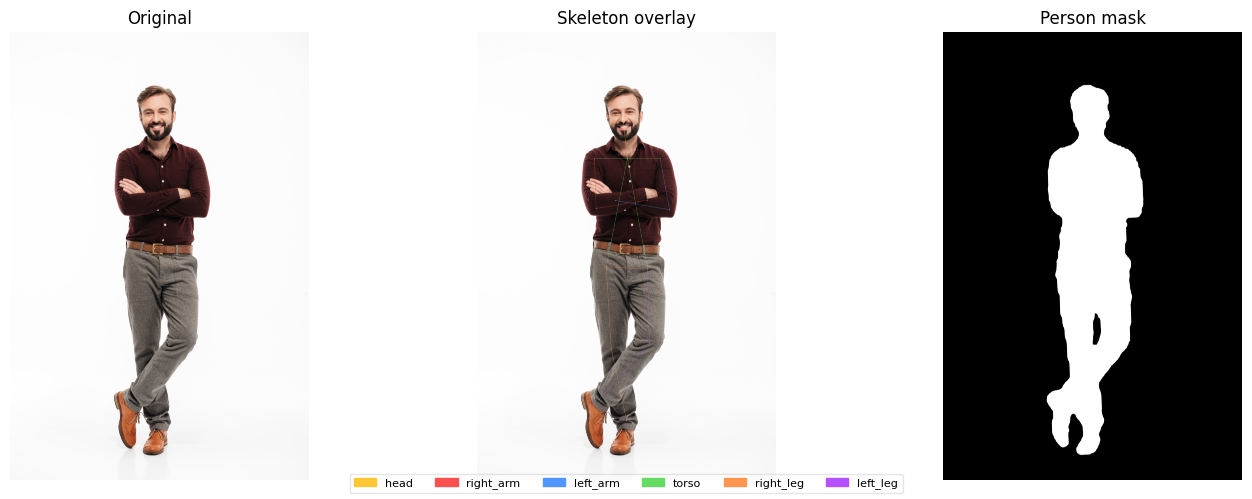

In [8]:
# Visual summary — original, skeleton, mask
show_results(result)

## Step 8 — Generate and inspect heatmaps

Heatmap shape: (18, 7360, 4912)
Value range:   [0.000, 1.000]


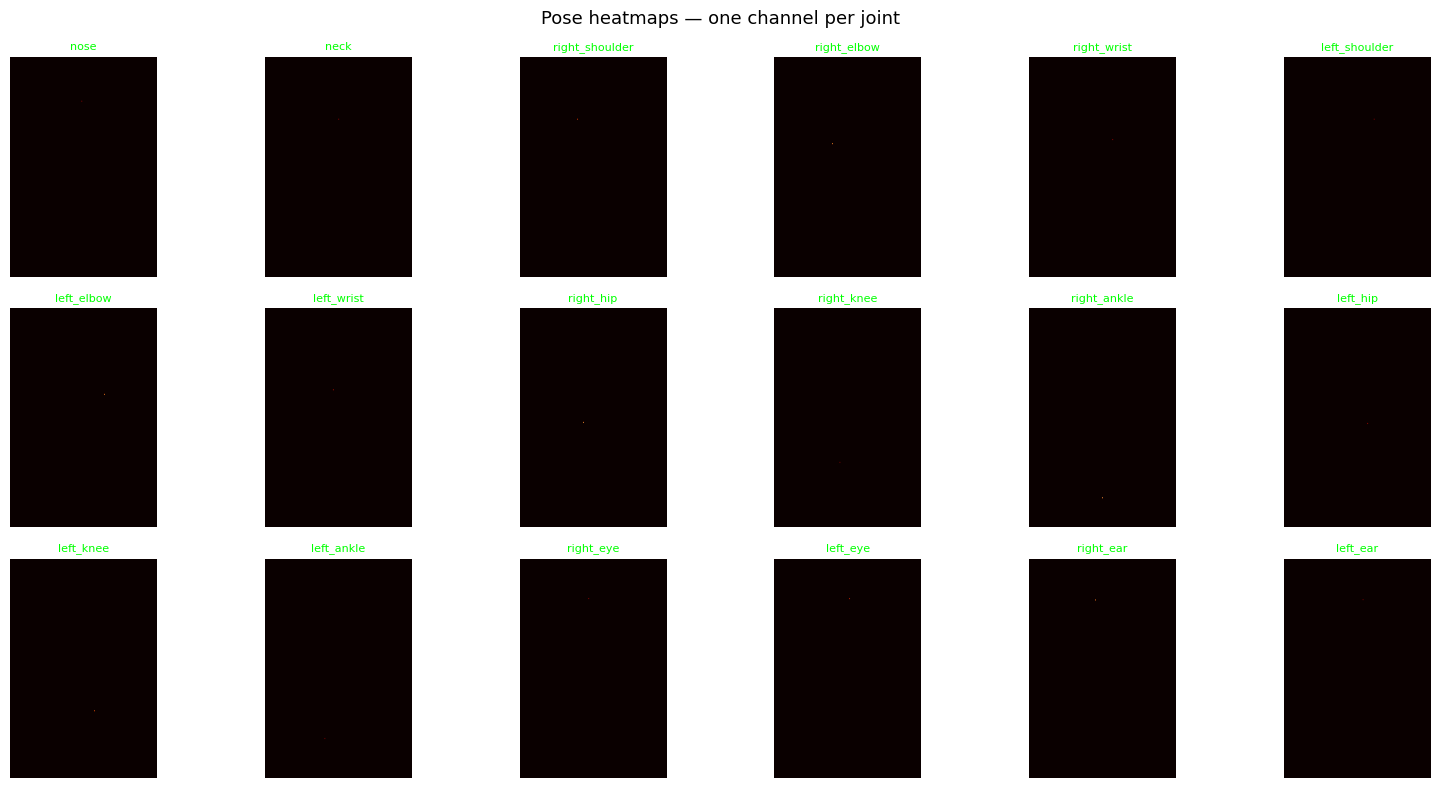

In [9]:
h, w = result['image'].shape[:2]

# Generate the 18-channel heatmap stack
heatmaps = generate_pose_heatmap(result['keypoints'], h, w, sigma=8)

print(f"Heatmap shape: {heatmaps.shape}")
print(f"Value range:   [{heatmaps.min():.3f}, {heatmaps.max():.3f}]")

# Visualise each channel
visualise_heatmap_grid(heatmaps, result['keypoints'])

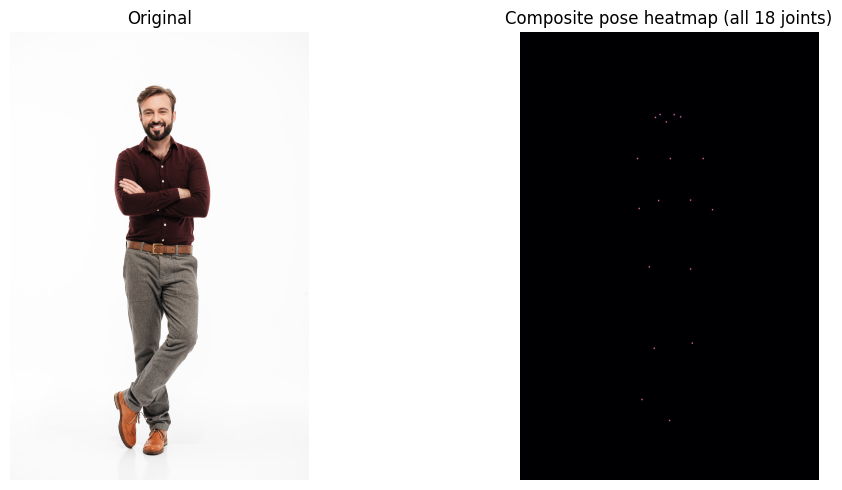

In [10]:
# Composite heatmap — sum all channels for a single-glance overview
composite = heatmaps.sum(axis=0)
composite = np.clip(composite, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
img_rgb = cv2.cvtColor(result['image'], cv2.COLOR_BGR2RGB)
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(composite, cmap='inferno')
axes[1].set_title('Composite pose heatmap (all 18 joints)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Step 9 — Save outputs

In [11]:
image_stem = Path(TEST_IMAGE_PATH).stem

# 1. Save skeleton overlay image
skeleton_img = draw_skeleton(result['image'], result['keypoints'])
skeleton_path = OUTPUT_DIR / f"{image_stem}_skeleton.jpg"
cv2.imwrite(str(skeleton_path), skeleton_img)
print(f"Skeleton image  : {skeleton_path}")

# 2. Save person segmentation mask
mask_path = OUTPUT_DIR / f"{image_stem}_mask.png"
cv2.imwrite(str(mask_path), result['mask'])
print(f"Segmentation mask: {mask_path}")

# 3. Save heatmaps as .npy (for use in training)
heatmap_path = OUTPUT_DIR / f"{image_stem}_heatmaps.npy"
np.save(str(heatmap_path), heatmaps)
print(f"Heatmaps (.npy)  : {heatmap_path}")

# 4. Save HR-VITON compatible JSON
json_path = OUTPUT_DIR / f"{image_stem}_keypoints.json"
keypoints_to_viton_json(result['keypoints'], json_path)

print("\nAll outputs saved successfully.")

Skeleton image  : outputs/pose/test-image_skeleton.jpg
Segmentation mask: outputs/pose/test-image_mask.png
Heatmaps (.npy)  : outputs/pose/test-image_heatmaps.npy
Saved: outputs/pose/test-image_keypoints.json

All outputs saved successfully.


## Step 10 — Batch processing

When you have the full VITON-HD dataset, use this cell to process all images at once.

In [ ]:
def batch_process(image_dir, output_dir, extensions=('.jpg', '.jpeg', '.png')):
    """
    Run pose estimation on all images in a directory.

    Args:
        image_dir  : folder containing person images
        output_dir : folder to save JSON + heatmaps
    """
    image_dir  = Path(image_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    image_paths = [p for p in image_dir.iterdir() if p.suffix.lower() in extensions]
    print(f"Found {len(image_paths)} images in {image_dir}")

    estimator = PoseEstimator()
    failed     = []

    for i, img_path in enumerate(sorted(image_paths)):
        try:
            result = estimator.process(img_path)

            if not result['detected']:
                failed.append(img_path.name)
                continue

            stem = img_path.stem
            h, w = result['image'].shape[:2]

            # Save JSON
            keypoints_to_viton_json(result['keypoints'], output_dir / f"{stem}_keypoints.json")

            # Save heatmaps
            hm = generate_pose_heatmap(result['keypoints'], h, w)
            np.save(str(output_dir / f"{stem}_heatmaps.npy"), hm)

            if (i + 1) % 50 == 0:
                print(f"  Processed {i+1}/{len(image_paths)}")

        except Exception as e:
            print(f"  ERROR on {img_path.name}: {e}")
            failed.append(img_path.name)

    estimator.close()

    print(f"\nDone. Processed: {len(image_paths) - len(failed)} | Failed: {len(failed)}")
    if failed:
        print("Failed images:", failed[:10])

# Example usage — uncomment when you have your dataset
# batch_process(
#     image_dir  = "data/viton_hd/train/image",
#     output_dir = "data/viton_hd/train/openpose_json"
# )

---
## Summary

| Output file | Shape / format | Used by |
|---|---|---|
| `*_keypoints.json` | 54 floats (18 × x,y,conf) | HR-VITON dataloader |
| `*_heatmaps.npy` | (18, H, W) float32 | GAN pose encoder |
| `*_mask.png` | (H, W) uint8 | Body segmentation module |
| `*_skeleton.jpg` | (H, W, 3) uint8 | Debugging / visual check |

**Next module:** Body segmentation — uses the mask from this module + a dedicated U-Net to generate the clothing-agnostic person image.